<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Introduction to plotting</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟢 Beginner</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Time to complete: ~10 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b><br>
<a href="https://explorer.dea.ga.gov.au/ga_ls8cls9c_gm_cyear_3">ga_ls8cls9c_gm_cyear_3</a>
</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://knowledge.dea.ga.gov.au/guides/setup/Sandbox/sandbox/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>

</div>

## Background
Data visualisation is an important component of working with Earth Observation data.
The `xarray` Python package provides a range of straightforward data plotting options that allow users to quickly generate simple plots from multidimensional datasets. 
To generate more complex and informative plots, the DEA Notebooks repository also provides a custom plotting module with additional easy-to-use functionality. 


## Description
This introductory notebook demonstrates how to visualise DEA satellite data returned from running a datacube query.
The notebook demonstrates commonly used `xarray` plotting methods, as well as custom functions provided in the [dea_tools.plotting](../Tools/dea_tools/plotting.py) module.

Topics covered in this notebook include:

1. View an area of interest prior to querying the datacube
2. Querying the datacube and loading data
3. Plotting single band data (e.g. a single satellite band)
    * Selecting and plotting individual timesteps
    * Plotting multiple timesteps
    * Customising plot appearance
4. Plotting three-band true or false colour imagery
    * Plotting single timesteps
    * Plotting multiple timesteps
    * Customising plot appearance

***

## Setup

### Load packages
The first step is to load the libraries needed to search STAC catalogs, load data, and a 
selection of custom DEA functions from the [dea_tools.plotting](https://docs.dea.ga.gov.au/notebooks/Beginners_guide/Tools/dea_tools/plotting.py) module.

In [1]:
import sys
import odc.stac
import pystac_client
from odc.geo import BoundingBox

sys.path.insert(1, '../Tools/')
from dea_tools.plotting import display_map, rgb

### Connect to DEA's STAC API
This allows us to search for data using DEA's STAC API (refer to the [SpatioTemporal Asset Catalogue guide](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) or [Loading data with STAC notebook](../Beginners_guide/04a_Loading_data_STAC.ipynb) for details).

To load data, we must also configure access to DEA's Amazon S3 buckets using `odc.stac.configure_s3_access`.
If launching a Dask client (e.g. `dea_tools.dask.create_local_dask_cluster()`), this is done automatically.

In [2]:
# Configure data access
odc.stac.configure_s3_access(cloud_defaults=True, aws_unsigned=True)

# Connect to DEA STAC API
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")


## Analysis

### Analysis parameters

First we need to define the location, time period and DEA product we want to load.
- `start_date`, `end_date`: The date range for this analysis. 
- `lat_range`, `lon_range`: The latitude and longitude range for your study area. For reasonable load times, keep this to a range of ~0.1 degrees or less.
- `collections`: The STAC product identifier. This specifies which dataset we want to load.

In [3]:
# Set a loading date - Landsat geomedians are annual products
start_date = "2013"
end_date = "2017"

# Set lat and lon range for study area
lat_range = (-27.58, -27.666)
lon_range = (153.3, 153.4)

# Set product ID as the STAC "collection"
collections = ["ga_ls8cls9c_gm_cyear_3"]

### Create and plot the bounding box region-of-interest

In [4]:
bbox = BoundingBox(
    left=min(lon_range),
    bottom=min(lat_range),
    right=max(lon_range),
    top=max(lat_range),
    crs="EPSG:4326",
)

bbox.explore()

### Searching for STAC data using `pystac_client`

We can use the `pystac_client` Python package to search for STAC items that match our query:

In [5]:
# Search the STAC catalog for all items matching the query
query = catalog.search(
    bbox=bbox,
    collections=collections,
    datetime=f"{start_date}/{end_date}",
)

# Convert to a list
items = list(query.items())
print(f"Found: {len(items):d} STAC items")

Found: 10 STAC items


### Loading data using `odc.stac.load()`

## Query and view data
The variables specified above are used to load data though `odc.stac.load()`, which was introduced in the [Loading data with STAC notebook](04a_Loading_data_STAC.ipynb).
This introduction will continue to use the GeoMAD product, as used in the [Loading data with STAC notebook](04a_Loading_data_STAC.ipynb).

In [6]:
ds = odc.stac.load(
    items,
    crs="EPSG:3577",  # geomedians are stored Albers Equal Area
    resolution=30,  # spatial resolution in metres
    bbox=bbox,
)

ds

<xarray.Dataset> Size: 28MB
Dimensions:       (y: 372, x: 375, time: 5)
Coordinates:
  * y             (y) float64 3kB -3.165e+06 -3.165e+06 ... -3.176e+06
  * x             (x) float64 3kB 2.066e+06 2.066e+06 ... 2.077e+06 2.077e+06
  * time          (time) datetime64[ns] 40B 2013-01-01 2014-01-01 ... 2017-01-01
    spatial_ref   int32 4B 3577
Data variables:
    edev          (time, y, x) float32 3MB 116.4 86.19 80.38 ... 162.9 156.3
    sdev          (time, y, x) float32 3MB 0.0006154 0.0001635 ... 0.001664
    bcdev         (time, y, x) float32 3MB 0.02473 0.01709 ... 0.03776 0.03605
    count         (time, y, x) float32 3MB 8.0 8.0 8.0 8.0 ... 11.0 11.0 11.0
    nbart_nir     (time, y, x) float32 3MB 2.484e+03 2.567e+03 ... 2.223e+03
    nbart_red     (time, y, x) float32 3MB 284.0 286.0 278.0 ... 326.0 346.0
    nbart_blue    (time, y, x) float32 3MB 236.0 244.0 235.0 ... 276.0 287.0
    nbart_green   (time, y, x) float32 3MB 354.0 369.0 358.0 ... 371.0 394.0
    nbart_swir_1  (time, y, x) float32 3MB 1.069e+03 1.093e+03 ... 1.2e+03
    nbart_swir_2  (time, y, x) float32 3MB 470.0 473.0 454.0 ... 530.0 543.0

## Plotting single band images

The `xarray` package provides built-in methods for plotting individual data variables or measurements.

To do this, identify the band to plot.
In this example, the `nbart_swir_1` satellite band is used.
To plot a single band, the data must be an `xarray.DataArray` (to revise the difference between `xarray.Dataset` and `xarray.DataArray` objects, refer back to the [Loading data with STAC](04a_Loading_dataSTAC.ipynb) notebook):

In [7]:
ds.nbart_swir_1

<xarray.DataArray 'nbart_swir_1' (time: 5, y: 372, x: 375)> Size: 3MB
array([[[1069., 1093., 1054., ...,   38.,   37.,   37.],
        [1085., 1074., 1021., ...,   37.,   36.,   36.],
        [1067., 1036.,  972., ...,   34.,   34.,   34.],
        ...,
        [1249., 1294.,  882., ..., 1097., 1092., 1139.],
        [ 810.,  801.,  745., ..., 1095., 1066., 1145.],
        [1123.,  882.,  865., ..., 1073., 1016., 1086.]],

       [[1128., 1139., 1110., ...,   46.,   45.,   47.],
        [1193., 1141., 1077., ...,   47.,   45.,   47.],
        [1221., 1144., 1053., ...,   47.,   45.,   47.],
        ...,
        [1355., 1344.,  906., ..., 1107., 1105., 1177.],
        [ 873.,  895.,  805., ..., 1100., 1070., 1171.],
        [1184.,  934.,  871., ..., 1086., 1021., 1088.]],

       [[1015., 1044., 1014., ...,   34.,   33.,   35.],
        [1055., 1045.,  977., ...,   33.,   33.,   30.],
        [1078., 1014.,  944., ...,   34.,   33.,   31.],
        ...,
        [1237., 1343.,  977., ..., 1066., 1038., 1095.],
        [ 799.,  828.,  832., ..., 1072., 1045., 1114.],
        [1225.,  885.,  843., ..., 1056.,  999., 1067.]],

       [[1068., 1071., 1039., ...,   38.,   38.,   38.],
        [1114., 1081., 1012., ...,   37.,   37.,   37.],
        [1140., 1061.,  987., ...,   37.,   37.,   36.],
        ...,
        [1287., 1343.,  980., ..., 1107., 1088., 1161.],
        [ 873.,  914.,  954., ..., 1101., 1059., 1157.],
        [1227.,  943.,  896., ..., 1090., 1029., 1103.]],

       [[1071., 1068., 1016., ...,   54.,   55.,   54.],
        [1063., 1048.,  975., ...,   55.,   57.,   56.],
        [1094., 1032.,  946., ...,   56.,   58.,   57.],
        ...,
        [1257., 1269.,  900., ..., 1250., 1193., 1228.],
        [ 898.,  880.,  899., ..., 1244., 1176., 1238.],
        [1232.,  969.,  939., ..., 1230., 1149., 1200.]]],
      shape=(5, 372, 375), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 40B 2013-01-01 2014-01-01 ... 2017-01-01
  * y            (y) float64 3kB -3.165e+06 -3.165e+06 ... -3.176e+06 -3.176e+06
  * x            (x) float64 3kB 2.066e+06 2.066e+06 ... 2.077e+06 2.077e+06
    spatial_ref  int32 4B 3577

### Selecting and plotting a single timestep

The returned object header above specifies that `ds.swir1` is a `xarray.DataArray` with five timesteps (i.e. `<xarray.DataArray 'swir1' (time: 5, y: 446, x: 450)>`).
To make a plot for a single timestep only, select the desired timestep using one of the following options:

1. `.isel()`: This stands for "index selection", which selects individual timesteps from a dataset based on the sequence of loaded timesteps. 
Counting in Python begins at 0, so to select the first timestep in the `xarray.DataArray` we can specify `.isel(time=0)`:

In [8]:
first_timestep = ds.nbart_swir_1.isel(time=0)

first_timestep

<xarray.DataArray 'nbart_swir_1' (y: 372, x: 375)> Size: 558kB
array([[1069., 1093., 1054., ...,   38.,   37.,   37.],
       [1085., 1074., 1021., ...,   37.,   36.,   36.],
       [1067., 1036.,  972., ...,   34.,   34.,   34.],
       ...,
       [1249., 1294.,  882., ..., 1097., 1092., 1139.],
       [ 810.,  801.,  745., ..., 1095., 1066., 1145.],
       [1123.,  882.,  865., ..., 1073., 1016., 1086.]],
      shape=(372, 375), dtype=float32)
Coordinates:
  * y            (y) float64 3kB -3.165e+06 -3.165e+06 ... -3.176e+06 -3.176e+06
  * x            (x) float64 3kB 2.066e+06 2.066e+06 ... 2.077e+06 2.077e+06
    spatial_ref  int32 4B 3577
    time         datetime64[ns] 8B 2013-01-01

2. `.sel()`: This selects data using real-world coordinate labels like `time`. 
    For example, from the **Coordinates** section, the first timestep (i.e. the year 2013) is selected from the `xarray.DataArray` by specifying `.sel(time='2013')`:

In [9]:
first_timestep = ds.nbart_swir_1.sel(time='2013')

first_timestep

<xarray.DataArray 'nbart_swir_1' (time: 1, y: 372, x: 375)> Size: 558kB
array([[[1069., 1093., 1054., ...,   38.,   37.,   37.],
        [1085., 1074., 1021., ...,   37.,   36.,   36.],
        [1067., 1036.,  972., ...,   34.,   34.,   34.],
        ...,
        [1249., 1294.,  882., ..., 1097., 1092., 1139.],
        [ 810.,  801.,  745., ..., 1095., 1066., 1145.],
        [1123.,  882.,  865., ..., 1073., 1016., 1086.]]],
      shape=(1, 372, 375), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 8B 2013-01-01
  * y            (y) float64 3kB -3.165e+06 -3.165e+06 ... -3.176e+06 -3.176e+06
  * x            (x) float64 3kB 2.066e+06 2.066e+06 ... 2.077e+06 2.077e+06
    spatial_ref  int32 4B 3577

After selecting a timestep, the `.plot()` method can be used to display the chosen `nbart_swir_1` data:

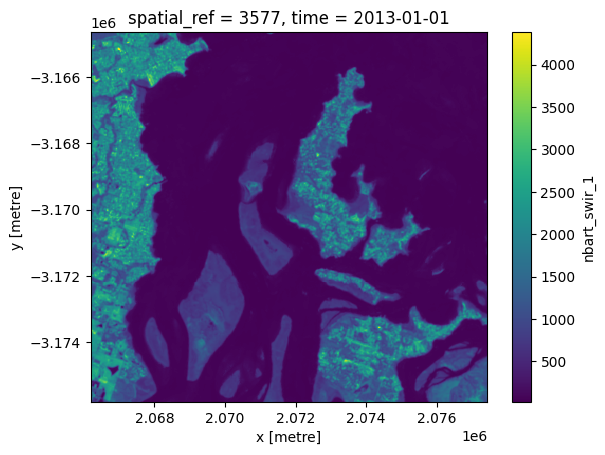

In [10]:
first_timestep.plot()

### Plotting multiple timesteps
It is often useful to produce plots for a single measurement across time, for example to compare change between satellite observations or summary datasets.
To plot multiple images, skip the `isel()` step above and plot the entire `xarray.DataArray` directly. 

To plot multiple timesteps in one figure, it is necessary to instruct the `.plot()` function to put each timestep in a different column.
This is done by specifying `.plot(col="time")`:

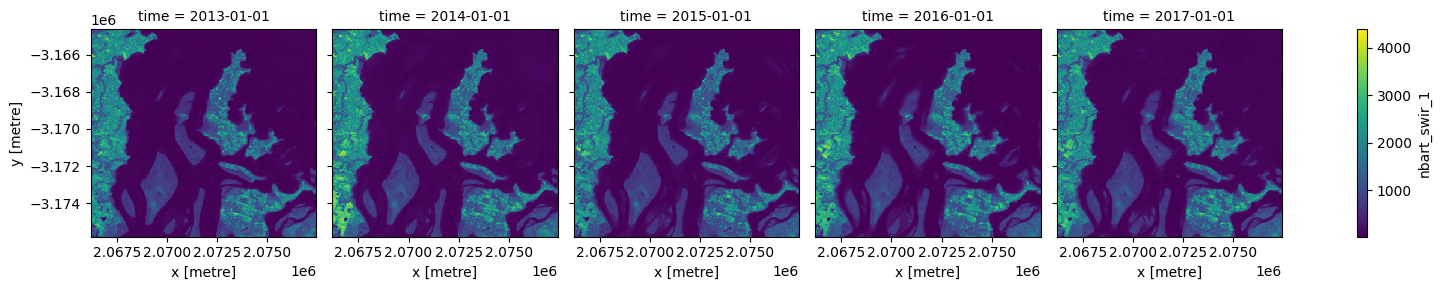

In [11]:
ds.nbart_swir_1.plot(col="time")

> This kind of plotting is called "facetted plotting". For more information, refer to the [xarray documentation](http://xarray.pydata.org/en/stable/plotting.html#faceting)

### Customising plot appearance
The plots above are dark and difficult to see clearly.
To improve the appearance of `xarray` plots, use the `robust=True` argument to optimise the plot colours by clipping extreme values or outliers. 
This will use the 2nd and 98th percentiles of the data to compute the color limits:

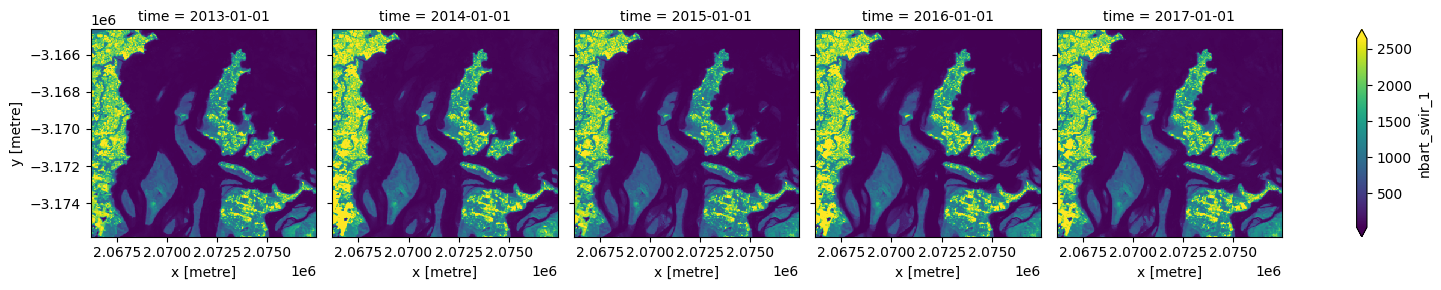

In [12]:
ds.nbart_swir_1.plot(col="time", robust=True)

Plots can be further customised by adding custom colour maps/styles using the `cmap` parameter.

When choosing a colour map for a plot, it is important to choose a set of colours that are perceived logically by the human eye. 
The best colour maps are "perceptually uniform": these colour maps increase logically from dark to light colours, where equal increases in lightness/darkness correspond to equal changes in data values. 
Some best-practice perceptually uniform colour maps include:

```
"viridis", "plasma", "inferno", "magma", "cividis"
```

> For further reading about perceptually uniform colour maps in data visualisation, refer to the [matplotlib documentation](https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html)

It is also important to consider colour blindness when selecting a colour map. 
`xarray` supports many colour maps from the "colorbrewer" family of colour maps which are optimised for colour blindness.
You can use the interactive [online tool](http://colorbrewer2.org) to browse all available colour maps, or choose from one of the following commonly used options:

```
"Greys", "Purples", "Blues", "Greens", "Oranges", "Reds",
"YlOrBr", "YlOrRd", "OrRd", "PuRd", "RdPu", "BuPu", 
"GnBu", "PuBu", "YlGnBu", "PuBuGn", "BuGn", "YlGn"
```

For a full list of available colour maps you can refer to [this list](https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html).

The example cell below plots the data with the perceptually uniform `magma` colour map:


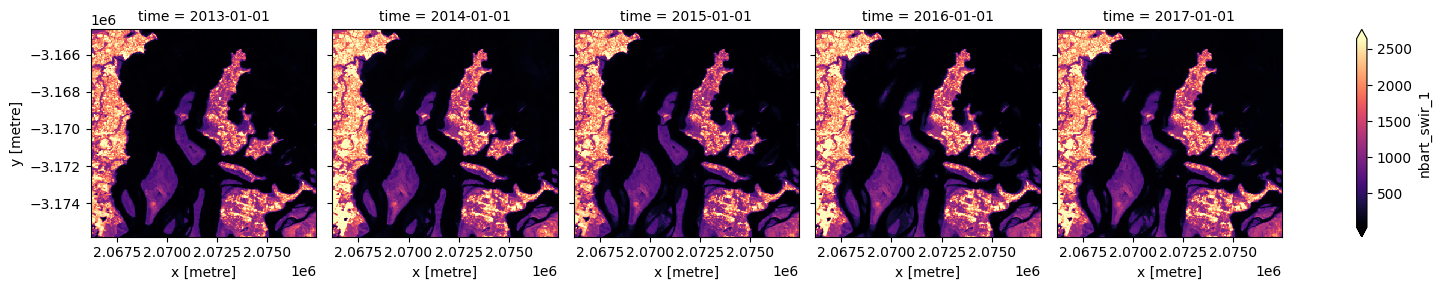

In [13]:
ds.nbart_swir_1.plot(col="time", robust=True, cmap="magma")

## Plotting true or false colour RGB images

Although `xarray` makes it easy to plot single band images, plotting a three band colour photo-like image is less straightforward.

To make this easier, the [dea-notebooks repository](https://github.com/GeoscienceAustralia/dea-notebooks) provides a custom `rgb()` function that is designed for plotting three band images.
The `rgb()` function maps three data variables/measurements from the loaded dataset to the red, green and blue channels that are used to make a three-colour image.

Providing the `nbart_red`, `nbart_green` and `nbart_blue` measurements from a dataset will produce a true colour image (akin to how humans view the landscape).
Providing `nbart_nir`, `nbart_red` and `nbart_green` measurements or any other set of three satellite bands from a dataset will produce a false colour image.

> [Learn more about colour rendering](https://en.wikipedia.org/wiki/False_color#True_color).

Hence, the `rgb()` function can be used to visualise the data returned by a query.
It requires the minimum input of:

* `ds:` The `xarray.Dataset` object
* `bands:` Three bands for display (these must be measurements found in the dataset) 
* `index:` The timestep to view, default is `0`

### Plotting a single timestep

The time dimension of an `xarray.Dataset` describes how many timesteps exist for the loaded data.
In the `rgb()` function, the `index` variable is asking for which timesteps to view (similar to the `isel()` example above).
Remember: counting in Python begins at 0 so to view the earliest timesteps set `index=0`:

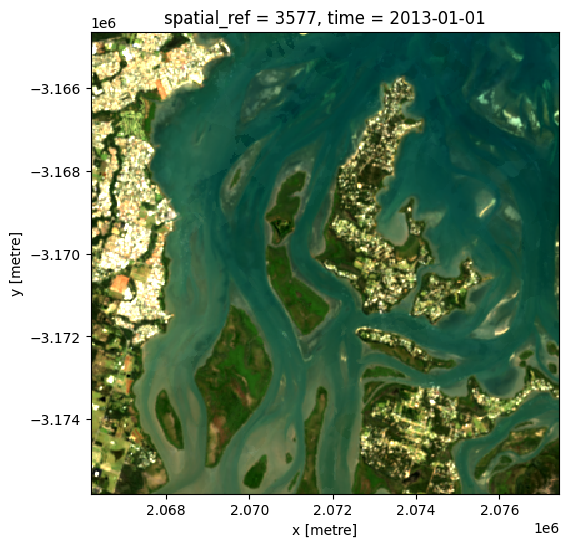

In [14]:
# View a red, green, blue (true colour) image of the first timestep
rgb(ds, bands=["nbart_red", "nbart_green", "nbart_blue"], index=0)

It is possible to change the input bands to plot a false colour image, which can provide different insights in a landscape.
The false colour band combination (`nbart_swir_1`, `nbart_nir`, `nbart_green`) emphasises growing vegetation in green, and water in deep blue:

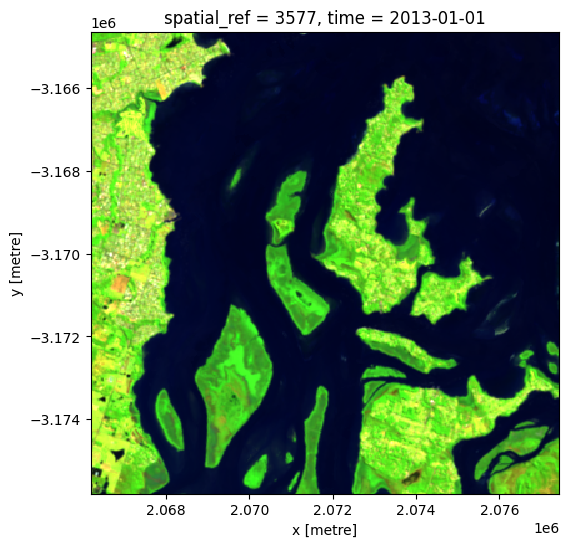

In [15]:
# View a swir1, nir, green (false colour) image of the first timestep
rgb(ds, bands=['nbart_swir_1', 'nbart_nir', 'nbart_green'], index=0)

### Plotting multiple timesteps
As discussed in the [single band example above](#Plotting-multiple-timesteps), it can be useful to visualise multiple timesteps in a single plot (e.g. to compare change over time).

The `rgb()` function can also do this, as long as a list of timesteps to view is provided to the `index` argument, e.g. `index=[X1, X2, ...]`.
The example cell below plots the first and fifth image in the dataset using `index=[0, 4]` (remembering that counting in Python starts at 0):

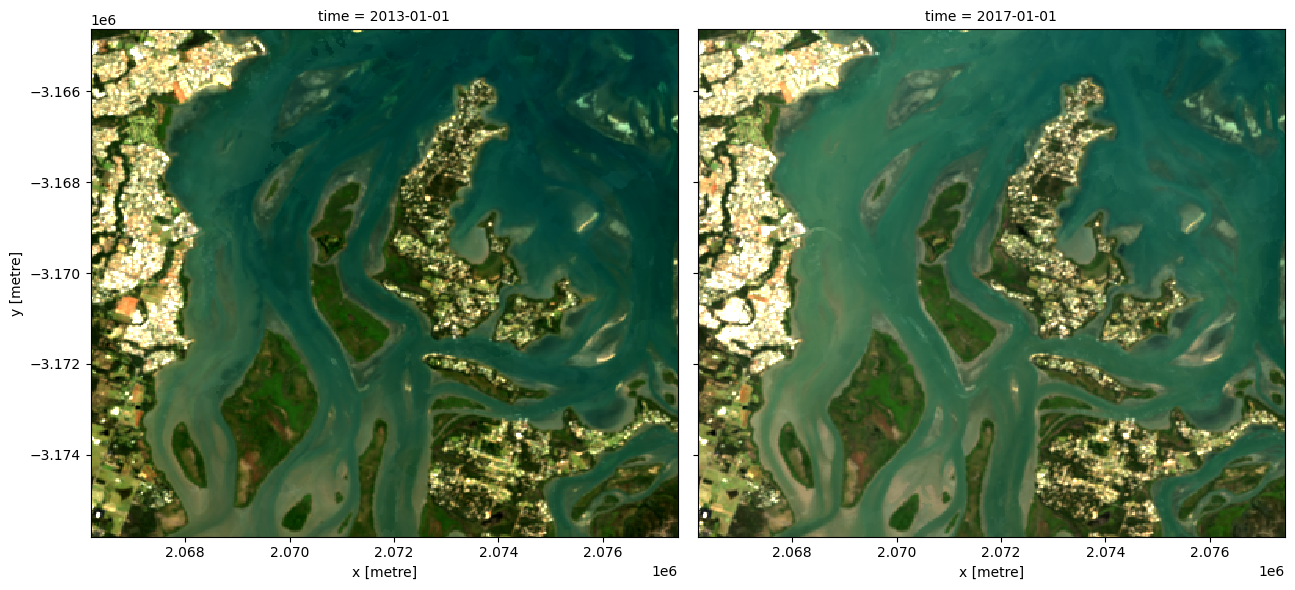

In [16]:
# View a true colour image for the first and fifth timesteps
rgb(ds, bands=['nbart_red', 'nbart_green', 'nbart_blue'], index=[0, 4])

It is also possible to use `rgb()` to plot all timesteps in a dataset using the `col="time"` syntax demonstrated in the [single band example above](#Plotting-multiple-timesteps): 

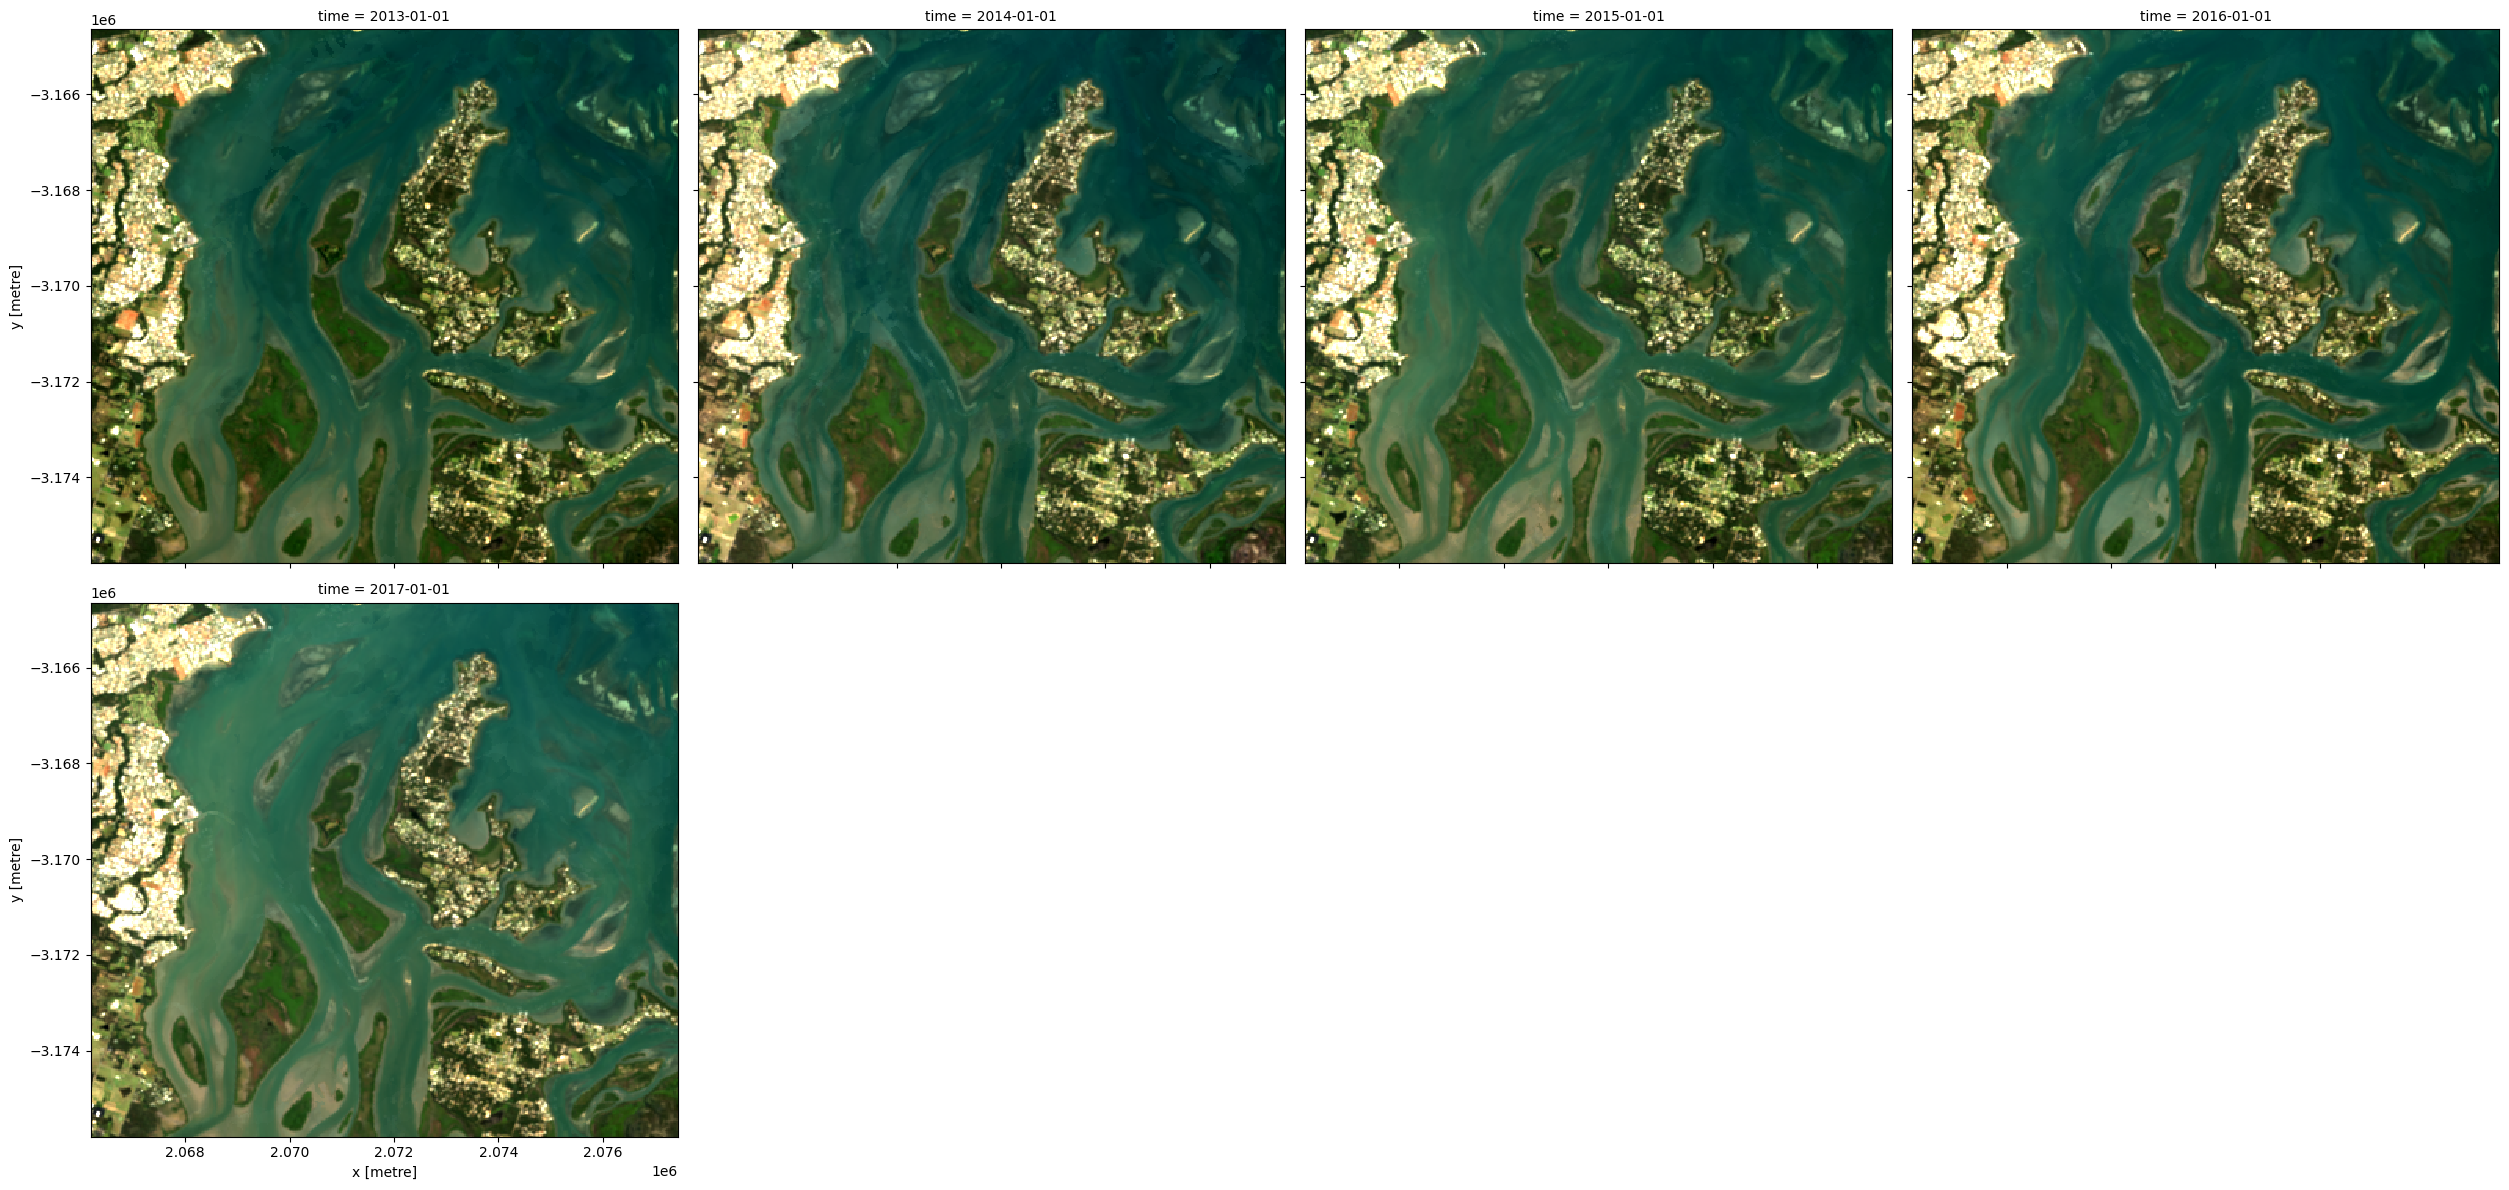

In [17]:
# Plot all timesteps in the dataset
rgb(ds, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col="time")

### Customising plot appearance
By default, `rgb()` generates plots with `robust=True` to improve the appearance of the images by clipping out the darkest and brightest 2% of pixels, using the 2nd and 98th percentiles of the data to compute the colour limits

If this default provides poor results, the plot's colour stretch can be customised using the `percentile_stretch` parameter. 
This clips the most extreme minimum and maximum values in the dataset, improving the contrast and appearance of the plot.

For example, specifying `percentile_stretch=[0.05, 0.95]` will clip out the darkest and brightest 5% of pixels, focusing the colour stretch on the remaining 90% of less extreme values:

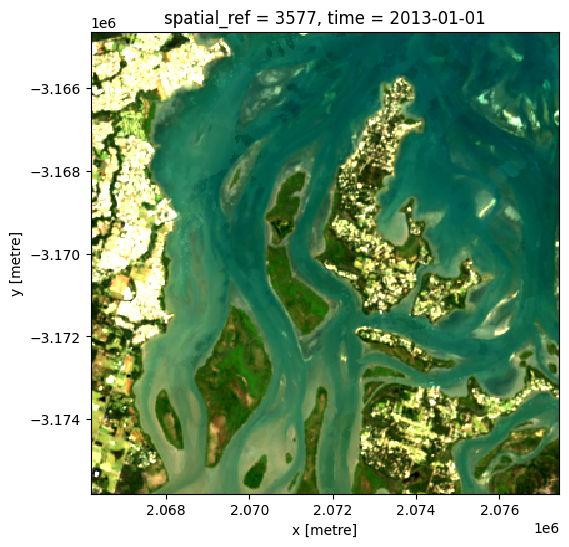

In [18]:
rgb(ds, 
    bands=['nbart_red', 'nbart_green', 'nbart_blue'], 
    index=0, 
    percentile_stretch=[0.05, 0.95])


## Recommended next steps

To continue working through the notebooks in this beginner's guide, the following notebooks are designed to be worked through in the following order:

1. [Jupyter Notebooks](01_Jupyter_notebooks.ipynb)
2. [Digital Earth Australia](02_DEA.ipynb)
3. [Products and measurements](03_Products_and_measurements.ipynb)
4. [Loading data with STAC](04a_Loading_data_STAC.ipynb) (or [Loading data with datacube](04b_Loading_data_datacube.ipynb))
5. **Plotting (this notebook)**
6. [Performing a basic analysis](06_Basic_analysis.ipynb)
7. [Introduction to Numpy](07_Intro_to_numpy.ipynb)
8. [Introduction to Xarray](08_Intro_to_xarray.ipynb)
9. [Parallel processing with Dask](09_Parallel_processing_with_Dask.ipynb)

For advanced plotting and visualisation options, see:

* The [dea_tools.plotting](../Tools/dea_tools/temporal.py) module containing functions used for plotting and visualising DEA data.

Once you have you have completed the beginner tutorials, join advanced users in exploring:

* The "DEA products" directory in the repository, where you can explore DEA products in depth.
* The "How_to_guides" directory, which contains a recipe book of common techniques and methods for analysing DEA data.
* The "Real_world_examples" directory, which provides more complex workflows and analysis case studies.




***
## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**

In [19]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-10'